In [2]:
# %%
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import pandas as pd
import glob
import PIL
from PIL import Image
import matplotlib.pyplot as plt
import os
import re
import cv2

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

%matplotlib inline

Using device: cuda


In [3]:
# %%
def jaccard_distance(y_true, y_pred, smooth=0.01):
    # Flatten tensors
    y_true = y_true.view(-1)
    y_pred = y_pred.view(-1)
    
    intersection = (torch.abs(y_true * y_pred)).sum()
    sum_ = (y_true ** 2).sum() + (y_pred ** 2).sum()
    jac = (intersection + smooth) / (sum_ - intersection + smooth)
    return (1 - jac)

def iou(y_true, y_pred, smooth=0.01):
    # Flatten tensors
    y_true = y_true.view(-1)
    y_pred = y_pred.view(-1)
    
    intersection = (torch.abs(y_true * y_pred)).sum()
    sum_ = (y_true ** 2).sum() + (y_pred ** 2).sum()
    jac = (intersection + smooth) / (sum_ - intersection + smooth)
    return jac

def bce_jaccard_loss(y_true, y_pred):
    bce = F.binary_cross_entropy(y_pred, y_true)
    jac = jaccard_distance(y_true, y_pred)
    
    # Give Jaccard 80% of the weight and BCE 20%
    return (0.2 * bce) + (0.8 * jac)

In [4]:
# %%
# To read the images in numerical order
numbers = re.compile(r'(\d+)')
def numericalSort(value):
    parts = numbers.split(value)
    parts[1::2] = map(int, parts[1::2])
    return parts

# Base directory based on your provided path
base_dir = r'/workspace/'

# Globbing files
filelist_trainx = sorted(glob.glob(os.path.join(base_dir, 'trainx', '*.jpg')), key=numericalSort)
filelist_trainy = sorted(glob.glob(os.path.join(base_dir, 'trainy', '*.jpg')), key=numericalSort)

filelist_testx = sorted(glob.glob(os.path.join(base_dir, 'testx', '*.jpg')), key=numericalSort)
filelist_testy = sorted(glob.glob(os.path.join(base_dir, 'testy', '*.jpg')), key=numericalSort)

filelist_valx = sorted(glob.glob(os.path.join(base_dir, 'validationx', '*.jpg')), key=numericalSort)
filelist_valy = sorted(glob.glob(os.path.join(base_dir, 'validationy', '*.jpg')), key=numericalSort)

print(f"Train samples: {len(filelist_trainx)}")
print(f"Test samples: {len(filelist_testx)}")
print(f"Val samples: {len(filelist_valx)}")

Train samples: 485
Test samples: 41
Val samples: 40


In [5]:
import torchvision.transforms.functional as TF
import random

class BrainTumorDataset(Dataset):
    def __init__(self, image_paths, mask_paths, is_train=False):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.is_train = is_train # Flag to determine if we should augment
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # 1. Load Image and Mask as PIL Images (Transforms require PIL or Tensors)
        img_path = self.image_paths[idx]
        image = Image.open(img_path)
        
        mask_path = self.mask_paths[idx]
        mask = Image.open(mask_path)
        
        # 2. Apply Data Augmentation (ONLY if this is the training set)
        if self.is_train:
            # 50% chance to flip horizontally
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            
            # 50% chance to flip vertically
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)
                
            # Random rotation between -20 and +20 degrees
            angle = random.uniform(-20, 20)
            image = TF.rotate(image, angle)
            mask = TF.rotate(mask, angle)

        # 3. Convert back to numpy, normalize to [0, 1], and make PyTorch Tensors
        image = np.array(image)
        mask = np.array(mask)
        
        image = torch.from_numpy(image).float() / 255.0
        mask = torch.from_numpy(mask).float() / 255.0
        
        # 4. Ensure dimensions are (Channels, Height, Width)
        if len(image.shape) == 3:
            image = image.permute(2, 0, 1) # HWC -> CHW
            
        if len(mask.shape) == 2:
            mask = mask.unsqueeze(0) # HW -> 1HW
        elif len(mask.shape) == 3:
            mask = mask.permute(2, 0, 1)

        return image, mask

# --- REPLACING THE DATALOADER SETUP ---
# Notice we set is_train=True ONLY for the training dataset
train_dataset = BrainTumorDataset(filelist_trainx, filelist_trainy, is_train=True)
val_dataset = BrainTumorDataset(filelist_valx, filelist_valy, is_train=False)
test_dataset = BrainTumorDataset(filelist_testx, filelist_testy, is_train=False)

# CRITICAL FIX: Set shuffle=True for your train_loader!
# If you don't shuffle, the model can memorize the sequence of the images, causing more overfitting.
# Use pin_memory=True to speed up transfer to the 4060
# num_workers=4 uses CPU cores to "pre-load" batches so the GPU never waits
# 1. Change num_workers to 0 to fix the freeze
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, pin_memory=True, num_workers=0) 
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, pin_memory=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, pin_memory=True, num_workers=0)

y shape = (256, 256, 1)


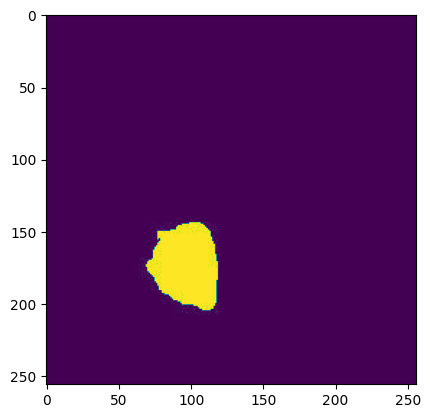

In [6]:
# %%
# Visualizing a sample from validation set
index = 13
# Get specific item from dataset
val_img, val_mask = val_dataset[index]

# Convert back to numpy for plotting (C
# HW -> HWC)
plt_mask = val_mask.permute(1, 2, 0).numpy()
plt.imshow(np.squeeze(plt_mask))
print("y shape = " + str(plt_mask.shape))

In [7]:
# %%
def UnPooling2x2ZeroFilled(x):
    # PyTorch implementation of the logic (though specific layers used below are ConvTranspose)
    # This creates a zero-filled upsample
    n, c, h, w = x.size()
    x = x.view(n, c, h, 1, w, 1)
    x = torch.cat([x, torch.zeros_like(x)], dim=5)
    x = torch.cat([x, torch.zeros_like(x)], dim=3)
    return x.view(n, c, h * 2, w * 2)

In [8]:
# %%
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm.notebook import tqdm

class NMinusOneNet(nn.Module):
    def __init__(self):
        super(NMinusOneNet, self).__init__()
        
        # Helper to keep the code clean
        def conv_block(in_c, out_c, kernel_size=3, padding=1):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size, padding=padding),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        # --- ENCODER ---
        self.e1_conv = nn.Sequential(conv_block(3, 16), conv_block(16, 32))
        self.pool1 = nn.MaxPool2d(2)
        
        self.e2_conv = nn.Sequential(conv_block(32, 64), conv_block(64, 64))
        self.pool2 = nn.MaxPool2d(2)
        
        self.e3_conv = nn.Sequential(conv_block(64, 128), conv_block(128, 128))
        self.pool3 = nn.MaxPool2d(2)
        
        # Preserving your original dropout logic
        self.e4_conv = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.Dropout(0.5),
            nn.ReLU(inplace=True),
            conv_block(256, 256)
        )
        self.pool4 = nn.MaxPool2d(2)
        
        self.e5_conv = conv_block(256, 512)

        # --- BOTTLENECK & ATTENTION ---
        self.fc1 = nn.Sequential(nn.Conv2d(512, 1024, kernel_size=1), nn.ReLU(inplace=True))
        self.attention_probs = nn.Sequential(nn.Conv2d(1024, 1024, kernel_size=1), nn.Softmax(dim=1))
        self.fc2 = nn.Sequential(nn.Conv2d(1024, 1024, kernel_size=1), nn.ReLU(inplace=True))

        # --- N-1 DOWNSAMPLING OPERATIONS ---
        # These shrink the encoder features to fit the next step down in the decoder
        self.down_e1 = nn.MaxPool2d(2)
        self.down_e2 = nn.MaxPool2d(2)
        self.down_e3 = nn.MaxPool2d(2)

        # --- DECODER WITH N-1 ROUTING ---
        self.up4 = nn.Upsample(scale_factor=2, mode='nearest')
        # Channels: 1024 (bottleneck) + 256 (e4 symmetric) + 128 (e3 N-1 diagonal) = 1408
        self.d4_conv = nn.Sequential(conv_block(1408, 256), conv_block(256, 256))

        self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        # Channels: 256 (d4) + 128 (e3 symmetric) + 64 (e2 N-1 diagonal) = 448
        self.d3_conv = nn.Sequential(conv_block(448, 128), conv_block(128, 128))

        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        # Channels: 128 (d3) + 64 (e2 symmetric) + 32 (e1 N-1 diagonal) = 224
        self.d2_conv = nn.Sequential(conv_block(224, 64), conv_block(64, 64))

        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        # Channels: 64 (d2) + 32 (e1 symmetric) = 96 (No N-1 here as it's the top layer)
        self.d1_conv = nn.Sequential(conv_block(96, 32), conv_block(32, 16))

        # Final output layer
        self.final_conv = nn.Sequential(
            nn.Conv2d(16, 1, 3, padding=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 1. Encoder Pass
        e1 = self.e1_conv(x)
        e2 = self.e2_conv(self.pool1(e1))
        e3 = self.e3_conv(self.pool2(e2))
        e4 = self.e4_conv(self.pool3(e3))
        e5 = self.e5_conv(self.pool4(e4))

        # 2. Bottleneck Pass
        b = self.fc1(e5)
        att = self.attention_probs(b)
        b = b * att
        b = self.fc2(b)

        # 3. Decoder Pass (The N-1 Magic)
        
        # Block 4: Connects Upsampled Bottleneck + Symmetric E4 + Diagonal E3
        d4_in = self.up4(b)
        e3_n1 = self.down_e3(e3)
        d4_cat = torch.cat([d4_in, e4, e3_n1], dim=1) 
        d4 = self.d4_conv(d4_cat)

        # Block 3: Connects Upsampled D4 + Symmetric E3 + Diagonal E2
        d3_in = self.up3(d4)
        e2_n1 = self.down_e2(e2)
        d3_cat = torch.cat([d3_in, e3, e2_n1], dim=1) 
        d3 = self.d3_conv(d3_cat)

        # Block 2: Connects Upsampled D3 + Symmetric E2 + Diagonal E1
        d2_in = self.up2(d3)
        e1_n1 = self.down_e1(e1)
        d2_cat = torch.cat([d2_in, e2, e1_n1], dim=1) 
        d2 = self.d2_conv(d2_cat)

        # Block 1: Connects Upsampled D2 + Symmetric E1
        d1_in = self.up1(d2)
        d1_cat = torch.cat([d1_in, e1], dim=1) 
        d1 = self.d1_conv(d1_cat)

        # Final prediction map
        out = self.final_conv(d1)
        return out

model = NMinusOneNet().to(device)

# Training Loop Setup
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5, verbose=True)

def train_model(model, loader, val_loader, epochs=500):
    best_loss = float('inf')
    
    # Pre-allocate some VRAM
    torch.cuda.empty_cache()
    
    for epoch in range(epochs):
        model.train()
        train_loss, train_iou = 0, 0
        
        train_loop = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        
        for imgs, masks in train_loop:
            # non_blocking=True is faster when pin_memory is used
            imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            
            
            optimizer.zero_grad(set_to_none=True) # Slightly faster than zero_grad()
            outputs = model(imgs)
            
            loss = bce_jaccard_loss(masks, outputs)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_iou += iou(masks, outputs).item()
            train_loop.set_postfix(loss=loss.item())
            
        # Validation
        model.eval()
        val_loss, val_iou = 0, 0
        with torch.no_grad():
            val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
            for imgs, masks in val_loop:
                imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
                outputs = model(imgs)
                
                batch_loss = bce_jaccard_loss(masks, outputs).item()
                val_loss += batch_loss
                val_iou += iou(masks, outputs).item()
                val_loop.set_postfix(loss=batch_loss)
        
        avg_val_loss = val_loss / len(val_loader)
        print(f"Epoch {epoch+1}/{epochs} - Train IoU: {train_iou/len(loader):.4f} | Val IoU: {val_iou/len(val_loader):.4f}")
        
        scheduler.step(avg_val_loss)
        
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(model.state_dict(), "model.pth")
            
# Run training
train_model(model, train_loader, val_loader, epochs=200)

Epoch 1/200 [Train]:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 1/200 [Val]:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/200 - Train IoU: 0.0327 | Val IoU: 0.0156


Epoch 2/200 [Train]:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 2/200 [Val]:   0%|          | 0/3 [00:00<?, ?it/s]

...

Epoch 199/200 [Val]:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 199/200 - Train IoU: 0.6261 | Val IoU: 0.5999


Epoch 200/200 [Train]:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 200/200 [Val]:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 200/200 - Train IoU: 0.6285 | Val IoU: 0.6221


In [9]:
# %%
# Load best model
model.load_state_dict(torch.load("model.pth"))
model.eval()

test_iou = 0
with torch.no_grad():
    for imgs, masks in test_loader: # Using test set for final eval as per Keras code (x_test passed to predict)
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        test_iou += iou(masks, outputs).item()

avg_test_iou = test_iou / len(test_loader)
print("Accuracy (IoU): ", avg_test_iou)

Accuracy (IoU):  0.7889821926752726


In [10]:
# %%
index = 6
# Get raw data from dataset (returns tensor)
predict_input_tensor, ground_truth_tensor = val_dataset[index]

# Prepare for display (Numpy, HWC)
predict_input = predict_input_tensor.permute(1, 2, 0).numpy() * 255.0
ground_truth = ground_truth_tensor.permute(1, 2, 0).numpy()

In [11]:
# %%
import cv2

# Predict
model.eval()
input_batch = predict_input_tensor.unsqueeze(0).to(device) # Add batch dim

with torch.no_grad():
    prediction_tensor = model(input_batch)

prediction = prediction_tensor.squeeze().cpu().numpy() # Remove batch/channel dims -> (256, 256)

# Post processing (matching original math)
prediction = prediction * 150
prediction = 225 - prediction

# Convert to RGB equivalent for overlay
prediction = prediction.astype(np.uint8) # Ensure type is uint8 for cv2
cover = cv2.cvtColor(prediction, cv2.COLOR_GRAY2BGR)
cover = cover.astype(int)

predict_input = predict_input.astype(int)

In [12]:
# %%
# Creating the overlay
# Ensure shapes match exactly before addWeighted
if cover.shape != predict_input.shape:
    cover = cv2.resize(cover.astype(np.float32), (predict_input.shape[1], predict_input.shape[0])).astype(int)

predict_out = cv2.addWeighted(cover.astype(np.uint8), 0.3, predict_input.astype(np.uint8), 0.7, 0)

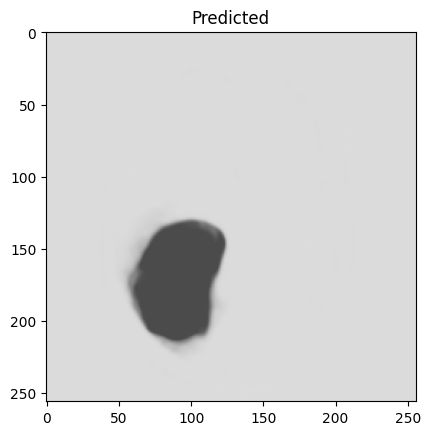

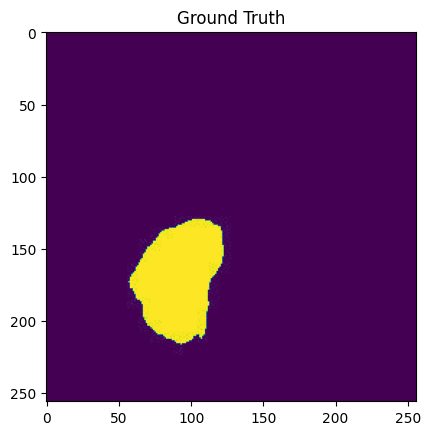

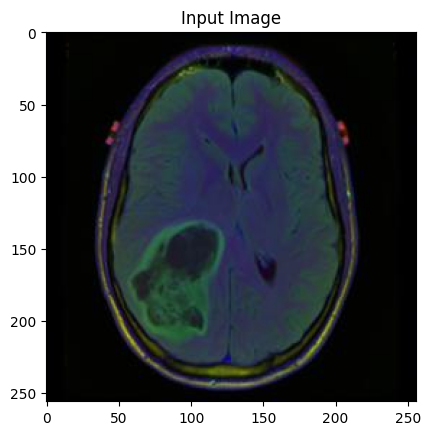

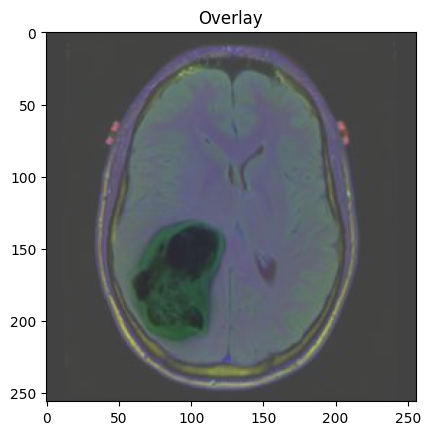

In [13]:
# %%
plt.figure()
plt.imshow(cover)
plt.title('Predicted')

plt.figure()
plt.imshow(np.squeeze(ground_truth))
plt.title('Ground Truth')

plt.figure()
plt.imshow(predict_input.astype(np.uint8))
plt.title('Input Image')

plt.figure()
plt.imshow(predict_out)
plt.title('Overlay')
plt.show()

In [14]:
# %%
# To print model summary in PyTorch
from torchsummary import summary
# Input size must match model input (Channels, H, W)
summary(model, input_size=(3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 256, 256]             448
       BatchNorm2d-2         [-1, 16, 256, 256]              32
              ReLU-3         [-1, 16, 256, 256]               0
            Conv2d-4         [-1, 32, 256, 256]           4,640
       BatchNorm2d-5         [-1, 32, 256, 256]              64
              ReLU-6         [-1, 32, 256, 256]               0
         MaxPool2d-7         [-1, 32, 128, 128]               0
            Conv2d-8         [-1, 64, 128, 128]          18,496
       BatchNorm2d-9         [-1, 64, 128, 128]             128
             ReLU-10         [-1, 64, 128, 128]               0
           Conv2d-11         [-1, 64, 128, 128]          36,928
      BatchNorm2d-12         [-1, 64, 128, 128]             128
             ReLU-13         [-1, 64, 128, 128]               0
        MaxPool2d-14           [-1, 64,

In [18]:
# Load best model
model.load_state_dict(torch.load("model.pth"))
model.eval()

test_iou = 0
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        
        # 1. Normal Prediction
        pred_normal = model(imgs)
        
        # 2. Horizontal Flip Prediction (flip width: dim 3)
        imgs_h = torch.flip(imgs, dims=[3])
        pred_h = model(imgs_h)
        pred_h = torch.flip(pred_h, dims=[3]) # Flip the prediction back to normal orientation
        
        # 3. Vertical Flip Prediction (flip height: dim 2)
        imgs_v = torch.flip(imgs, dims=[2])
        pred_v = model(imgs_v)
        pred_v = torch.flip(pred_v, dims=[2]) # Flip back
        
        # 4. Ensemble the Predictions (Average them)
        final_prediction = (pred_normal + pred_h + pred_v) / 3.0
        
        # Calculate score on the ensembled prediction
        test_iou += iou(masks, final_prediction).item()

avg_test_iou = test_iou / len(test_loader)
print("Accuracy (IoU) with TTA: ", avg_test_iou)

Accuracy (IoU) with TTA:  0.7899723649024963


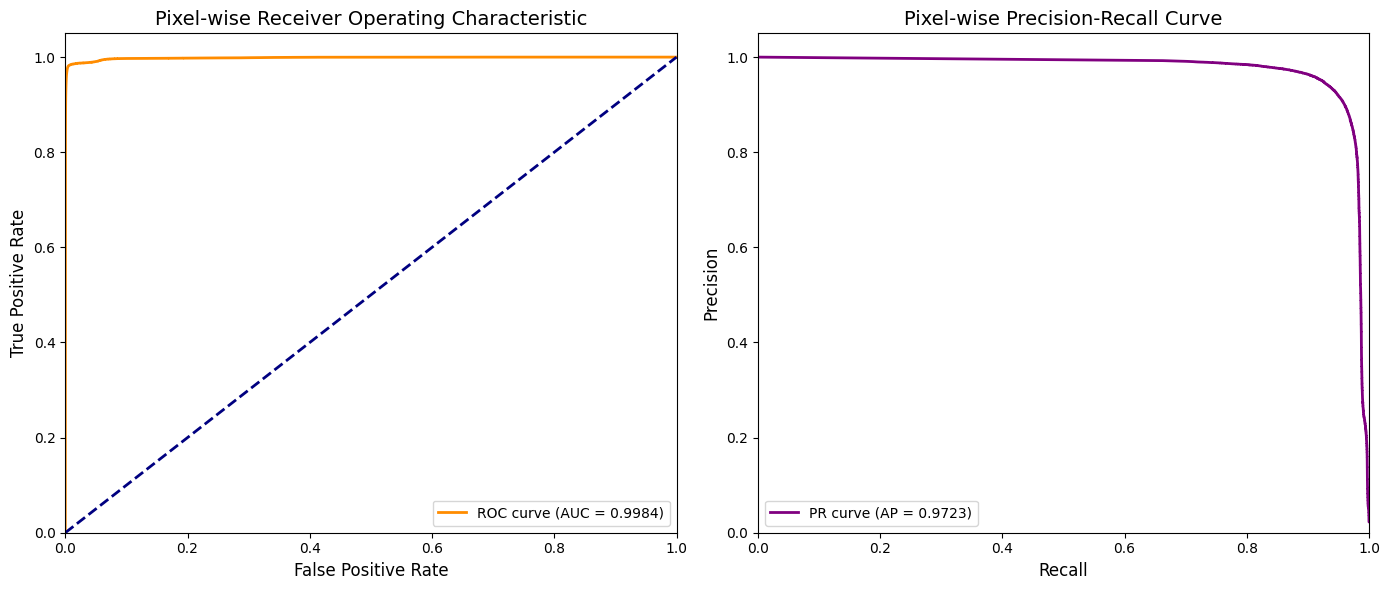

In [20]:
# %%
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np
import torch

# Put model in eval mode
model.load_state_dict(torch.load("model.pth"))
model.eval()

all_preds = []
all_trues = []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(device)
        # Using TTA (Test-Time Augmentation) for best results
        pred_normal = model(imgs)
        pred_h = torch.flip(model(torch.flip(imgs, dims=[3])), dims=[3])
        pred_v = torch.flip(model(torch.flip(imgs, dims=[2])), dims=[2])
        preds = (pred_normal + pred_h + pred_v) / 3.0
        
        # Flatten tensors to 1D arrays for sklearn
        all_preds.append(preds.cpu().numpy().flatten())
        all_trues.append(masks.cpu().numpy().flatten())

all_preds = np.concatenate(all_preds)
all_trues = np.concatenate(all_trues)

# --- CRITICAL FIX: Force ground truth to be strict binary integers ---
all_trues = (all_trues > 0.5).astype(int)

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(all_trues, all_preds)
roc_auc = auc(fpr, tpr)

# --- Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(all_trues, all_preds)
pr_auc = average_precision_score(all_trues, all_preds)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Plot
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('Pixel-wise Receiver Operating Characteristic', fontsize=14)
axes[0].legend(loc="lower right")

# PR Plot
axes[1].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Pixel-wise Precision-Recall Curve', fontsize=14)
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

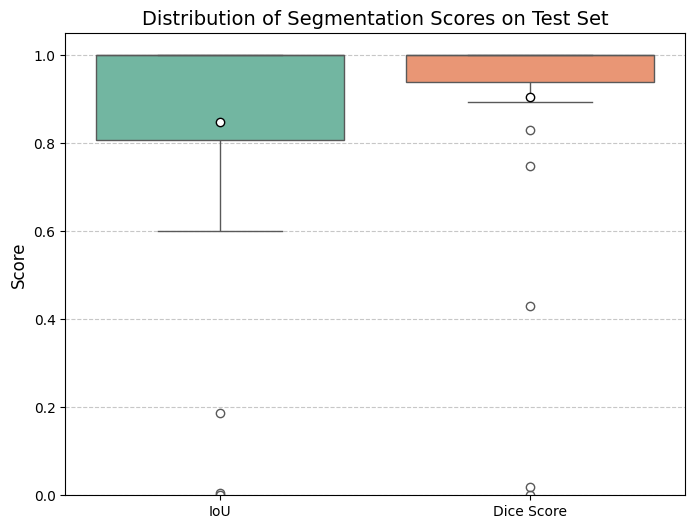

In [21]:
# %%
import seaborn as sns

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

image_ious = []
image_dices = []

model.eval()
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).cpu().numpy()
        masks = masks.cpu().numpy()
        
        # Calculate score per image in the batch
        for i in range(imgs.size(0)):
            # Threshold prediction at 0.5 to make it binary for exact scoring
            pred_bin = (preds[i] > 0.5).astype(np.float32)
            true_bin = masks[i]
            
            # Intersection over Union
            intersection = np.logical_and(true_bin, pred_bin).sum()
            union = np.logical_or(true_bin, pred_bin).sum()
            iou_score = (intersection + 1e-6) / (union + 1e-6)
            
            # Dice Score
            dice_score = dice_coef(true_bin, pred_bin)
            
            # Only append if there's actually a mask, or if you want to grade empty masks too
            image_ious.append(iou_score)
            image_dices.append(dice_score)

# --- Plotting ---
plt.figure(figsize=(8, 6))
data = pd.DataFrame({'IoU': image_ious, 'Dice Score': image_dices})
sns.boxplot(data=data, palette="Set2", showmeans=True, 
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
plt.title('Distribution of Segmentation Scores on Test Set', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

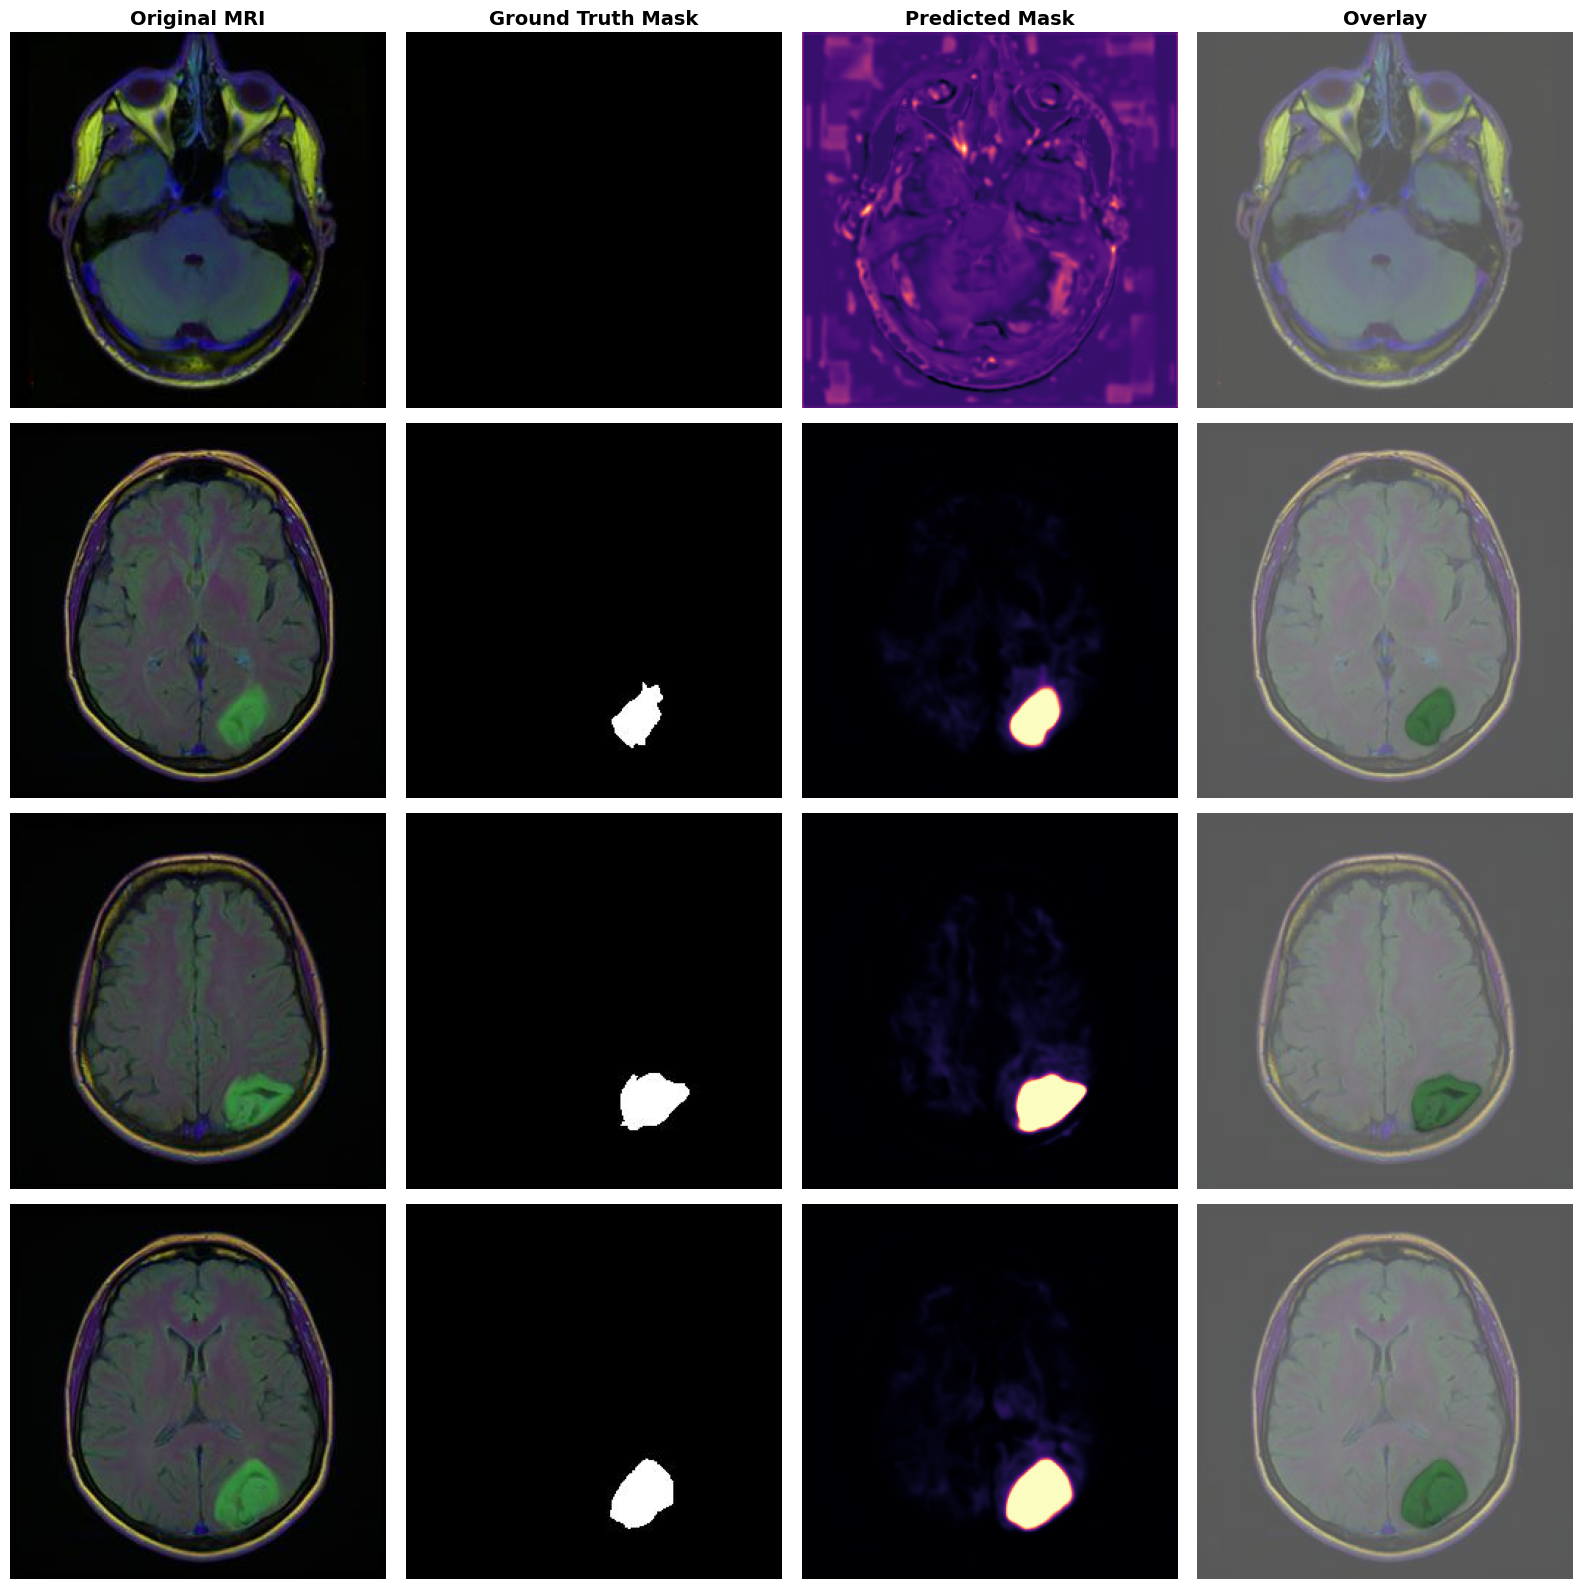

In [22]:
# %%
import cv2

# Select 4 random indices from the test dataset
num_samples = 4
indices = np.random.choice(len(test_dataset), num_samples, replace=False)

fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
titles = ['Original MRI', 'Ground Truth Mask', 'Predicted Mask', 'Overlay']

for i, ax in enumerate(axes[0]):
    ax.set_title(titles[i], fontsize=14, fontweight='bold')

model.eval()
with torch.no_grad():
    for row, idx in enumerate(indices):
        img_tensor, mask_tensor = test_dataset[idx]
        
        # Predict
        input_batch = img_tensor.unsqueeze(0).to(device)
        pred_tensor = model(input_batch).squeeze().cpu().numpy()
        
        # Format for display
        img_display = img_tensor.permute(1, 2, 0).numpy() * 255.0
        mask_display = mask_tensor.permute(1, 2, 0).numpy()
        
        # Process Prediction for Overlay
        pred_display = pred_tensor * 150
        pred_display = 225 - pred_display
        pred_display = pred_display.astype(np.uint8)
        cover = cv2.cvtColor(pred_display, cv2.COLOR_GRAY2BGR)
        
        # Create Overlay
        overlay = cv2.addWeighted(cover, 0.4, img_display.astype(np.uint8), 0.6, 0)
        
        # Plotting
        axes[row, 0].imshow(img_display.astype(np.uint8))
        axes[row, 0].axis('off')
        
        axes[row, 1].imshow(np.squeeze(mask_display), cmap='gray')
        axes[row, 1].axis('off')
        
        axes[row, 2].imshow(pred_tensor, cmap='magma') # Magma colormap looks very academic for predictions
        axes[row, 2].axis('off')
        
        axes[row, 3].imshow(overlay)
        axes[row, 3].axis('off')

plt.tight_layout()
plt.show()